In [1]:
import os


os.environ["CUDA_VISIBLE_DEVICES"] = "0,1"

import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = "cpu"


### Choose model for attribution

In [2]:
from transformers import AutoModelForCausalLM, AutoTokenizer
# Choose tokenizer and model

# model_name = "meta-llama/Llama-3.2-1B"
# model_name = "meta-llama/Llama-3.2-3B"
# model_name = "Qwen/Qwen2.5-3B"
# model_name = "Qwen/Qwen2.5-1.5B"
model_name = "google/gemma-3-1b-pt"
# model_name = "google/gemma-3-4b-pt"

tokenizer = AutoTokenizer.from_pretrained(model_name)
if device == "cpu":
    model = AutoModelForCausalLM.from_pretrained(model_name)
    model = model.to(device)
else:
    model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto")

### Select scope type

In [3]:
mode = 'Temperature'
# mode = 'Semantic'
# mode = 'Fisher'

### Set attribution prompt

In [4]:
# string = "Italian: Buon pomeriggio, i miei colleghi ricercatori. English: Good afternoon, my fellow researchers"
# string = "German: Dies ist ein Aufsatz über kausale Zuschreibung. English: This is a paper on causal attribution"
string = "French: Nous l'appelons lentille jacobienne. English: We call it Jacobian Scope"
# string = "Ari braced herself. I need you to take me to Azazil.\n\nGlass gave her a sharp, curious look but unlike Red, he didn't question her. All right. Now?\n\nPlease.\n\nVery well. He looked back at Trey and touched his cheek tenderly. Whatever passed between them caused Trey to glower and he turned to Ari"
# string = "For the hungrier set there seemed to be every kind of fowl, from quail to goose, neatly carved into small pieces so a dancer could eat quickly and return to the floor.\n\nOnce again I wished I was hungry for normal human food. But instead I indulged in a glass of champagne.\n\n\"Hilda, Hilda,\" Bridget called out in a voice that carried well considering how crowded the space was. A beautiful girl in a rose-pink gown turned from her gentleman friend, face lighting up when she saw Bridget"
# string = "\"Erin talked to a reporter,\" Liz told him. Erin was Brady's ex-girlfriend. They had broken up after he had visited Liz in October.\n\n\"What makes you think that? She's not the type to get involved with the press.\"\n\n\"She is the press,\" Liz reminded him. Erin worked as an anchor for Baltimore Mornings, though it was kind of a stretch in Liz's mind to call her press"
# string = "A small scream escaped her, but she landed in a shallow stream of frigid water. The fall had only been a meter or so.\n\n\"Watch out!\" Gray called.\n\nRachel rolled clear as the others slid, skidded, and dropped into the water with her. Rachel retrieved her cell phone from the edge of the stream"
string = "Every few hours, one of them wheeled in the portable ultrasound machine -- Josh during the day, and Nellie in the evenings.  Lashonda couldn't understand the monochrome squiggles on its greenish-black screen, but she could read the expression on Josh's face.  The set of his jowls was serious; the angle of his brows concerned.\n\"Of course,\" he said, his face transforming to jovial jocularity, \"we can't really tell from the ultrasound"

### Perform attribution

In [5]:
import JacobianScopes
print(f"JacobianScopes package path: {JacobianScopes.__file__}")

JacobianScopes package path: /home/jl3499/JacobianScopes/JacobianScopes/src/JacobianScopes/__init__.py


In [ ]:
scores, logits, decoded_tokens, grad_idx, loss_position = JacobianScopes.run_scope(model, 
                                                                                   tokenizer, 
                                                                                   string, 
                                                                                   mode, 
                                                                                   front_pad=2, 
                                                                                   loss_position=-2, 
                                                                                   device=device)
    

### Visualize prediction

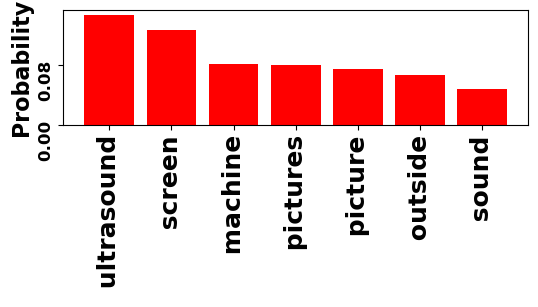

In [ ]:

logit_vector = logits[-2].detach()             
# Compute softmax probabilities
probs = torch.softmax(logit_vector, dim=-1)
JacobianScopes.natural_language_pred_plotter(probs, tokenizer, k = 7)

### Visualize attribution

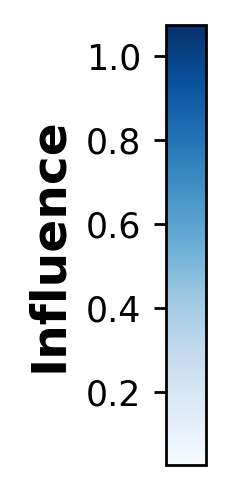

In [ ]:

JacobianScopes.natural_language_attribution_plotter(decoded_tokens, grad_idx, scores, mode, loss_position, style = 'B' )